# Simulation Results
### Shipping Reliability Simulator — Rotterdam → Singapore → Shanghai

---

**Purpose:** Run the Monte Carlo simulation, compute reliability KPIs, perform
sensitivity analysis, and compare scenarios. All outputs are saved to `figures/simulation/`
and `outputs/`.

**Inputs:**
| File | Used for |
|---|---|
| `data/processed/fitted_distributions.json` | Distribution parameters per port |
| `data/processed/congestion_monthly.csv` | Congestion indices for scenario modelling |

**Simulation parameters:**
- Route: Rotterdam → Singapore → Shanghai
- Scheduled total: **28 days**
- Iterations: **10,000** per run
- Seed: **42** (reproducible)
- Congestion: **2023 annual average** per port (most complete full year)

**Key results preview (from pre-flight check):**
- Simulated mean: 27.68 days
- P90: 29.62 days → reliability buffer of **1.62 days** over schedule
- On-time rate (±1d buffer): **81.35%**
- Dominant segment: Rotterdam → Singapore transit (75.9% of total journey)

---
## Imports

In [1]:
import sys
sys.path.append('..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Project modules ────────────────────────────────────────────────────────
from simulator.distributions import (
    load_fitted_params,
    get_distribution,
    get_congestion_multiplier
)
from simulator.route import Route, Segment
from simulator.monte_carlo import MonteCarloSimulator
from analysis.kpis import compute_kpis, compare_scenarios
from analysis.sensitivity import run_sensitivity, plot_tornado

In [2]:


# ── Paths ──────────────────────────────────────────────────────────────────
PROCESSED = Path('../data/processed')
FIGURES   = Path('../figures/simulation')
OUTPUTS   = Path('../outputs')
FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 12
plt.rcParams['axes.titleweight']  = 'bold'
sns.set_palette('muted')

# ── Constants ──────────────────────────────────────────────────────────────
SEED         = 42
N_ITERATIONS = 10_000
SCHEDULED    = 28.0          # total scheduled journey days
BUFFER_DAYS  = 1.0           # on-time tolerance

PORT_COLORS = {
    'Rotterdam': '#2196F3',
    'Singapore': '#E91E63',
    'Shanghai':  '#4CAF50'
}

# 2023 annual average congestion indices (from Notebook 01)
CONGESTION_2023 = {
    'Rotterdam': 0.8868,
    'Singapore': 0.9954,
    'Shanghai':  1.1180
}

print('✓ Imports and configuration loaded')
print(f'  Figures → {FIGURES}')
print(f'  Outputs → {OUTPUTS}')

✓ Imports and configuration loaded
  Figures → ../figures/simulation
  Outputs → ../outputs


---
## Load Fitted Parameters & Build Route

In [3]:
# Load fitted distributions from Notebook 02
fitted = load_fitted_params(PROCESSED / 'fitted_distributions.json')

print('Fitted distributions loaded:')
for port, data in fitted.items():
    print(f'  {port:<12} {data["best_distribution"]:<12} '
          f'params={[round(p,4) for p in data["params"]]}')

print(f'\n2023 congestion indices applied:')
for port, ci in CONGESTION_2023.items():
    strategy = fitted[port]['congestion_strategy']['type']
    mult     = get_congestion_multiplier(ci, port, fitted)
    print(f'  {port:<12} CI={ci}  strategy={strategy:<10} multiplier={mult:.4f}')

Fitted distributions loaded:
  Rotterdam    gamma        params=[3.9229, 0, 0.2426]
  Singapore    gamma        params=[4.1075, 0, 0.2415]
  Shanghai     gamma        params=[3.7046, 0, 0.2013]

2023 congestion indices applied:
  Rotterdam    CI=0.8868  strategy=dampened   multiplier=0.9660
  Singapore    CI=0.9954  strategy=inverse    multiplier=1.0023
  Shanghai     CI=1.118  strategy=none       multiplier=1.0000


In [4]:
# ── Build the route ────────────────────────────────────────────────────────
# Each segment has a scheduled duration and a stochastic delay distribution.
# Port segments use fitted Gamma distributions + congestion multipliers.
# Transit segments use Normal(scheduled, 0.06×scheduled) — documented assumption.

segments = [
    Segment(
        name               = 'Rotterdam port delay',
        scheduled_days     = 1.0,
        delay_distribution = get_distribution(
            fitted['Rotterdam']['best_distribution'],
            fitted['Rotterdam']['params']
        ),
        is_port         = True,
        congestion_port = 'Rotterdam'
    ),
    Segment(
        name               = 'Rotterdam → Singapore transit',
        scheduled_days     = 21.0,
        delay_distribution = stats.norm(loc=21.0, scale=21.0 * 0.06),
        is_port            = False
    ),
    Segment(
        name               = 'Singapore port delay',
        scheduled_days     = 1.0,
        delay_distribution = get_distribution(
            fitted['Singapore']['best_distribution'],
            fitted['Singapore']['params']
        ),
        is_port         = True,
        congestion_port = 'Singapore'
    ),
    Segment(
        name               = 'Singapore → Shanghai transit',
        scheduled_days     = 4.0,
        delay_distribution = stats.norm(loc=4.0, scale=4.0 * 0.06),
        is_port            = False
    ),
    Segment(
        name               = 'Shanghai port delay',
        scheduled_days     = 1.0,
        delay_distribution = get_distribution(
            fitted['Shanghai']['best_distribution'],
            fitted['Shanghai']['params']
        ),
        is_port         = True,
        congestion_port = 'Shanghai'
    ),
]

route = Route('Rotterdam → Singapore → Shanghai', segments)

print(route)
print(f'\nSegments:')
for s in route.segments:
    kind = 'PORT    ' if s.is_port else 'TRANSIT '
    print(f'  {kind} {s.name:<42} scheduled={s.scheduled_days:.1f}d')
print(f'\nTotal scheduled: {route.scheduled_total:.1f} days')

Route('Rotterdam → Singapore → Shanghai', 5 segments, scheduled=28.0d)

Segments:
  PORT     Rotterdam port delay                       scheduled=1.0d
  TRANSIT  Rotterdam → Singapore transit              scheduled=21.0d
  PORT     Singapore port delay                       scheduled=1.0d
  TRANSIT  Singapore → Shanghai transit               scheduled=4.0d
  PORT     Shanghai port delay                        scheduled=1.0d

Total scheduled: 28.0 days


---
## Baseline Simulation

**Baseline scenario:** 2023 annual average congestion indices for all three ports.
This represents current, real-world operating conditions.

In [5]:
sim = MonteCarloSimulator(
    route              = route,
    seed               = SEED,
    fitted_params      = fitted,
    congestion_indices = CONGESTION_2023
)

results = sim.run(n_iterations=N_ITERATIONS)

print('Simulation complete.')
print(f'  Iterations : {N_ITERATIONS:,}')
print(f'  Seed       : {SEED}')
print(f'  Runtime    : see cell execution time above')

Simulation complete.
  Iterations : 10,000
  Seed       : 42
  Runtime    : see cell execution time above


---
## Reliability KPI Report

In [6]:
kpis = compute_kpis(results, SCHEDULED, BUFFER_DAYS, label='Baseline (2023 CI)')
summary = sim.summary()

print('=' * 60)
print('  RELIABILITY KPI REPORT')
print('  Route: Rotterdam → Singapore → Shanghai')
print('  Congestion: 2023 annual average')
print('=' * 60)
print(f'  Scheduled total          : {SCHEDULED:.1f} days')
print(f'  Simulated mean           : {summary["mean_days"]:.4f} days')
print(f'  Std deviation            : {summary["std_days"]:.4f} days')
print(f'  CV (std/mean)            : {kpis["cv"]:.4f}')
print()
print(f'  P50 (median)             : {summary["p50_days"]:.4f} days')
print(f'  P75                      : {summary["p75_days"]:.4f} days')
print(f'  P90                      : {summary["p90_days"]:.4f} days')
print(f'  P95                      : {summary["p95_days"]:.4f} days')
print(f'  P99 (worst case)         : {summary["p99_days"]:.4f} days')
print()
print(f'  On-time rate (±{BUFFER_DAYS:.0f}d)      : {summary["on_time_rate_pct"]:.2f}%')
print(f'  Reliability buffer (P90) : {summary["reliability_buffer_d"]:.4f} days')
print()
print(f'  Iterations               : {N_ITERATIONS:,}')
print(f'  Seed                     : {SEED}')
print('=' * 60)

# Save KPI report
kpis.to_json(OUTPUTS / 'kpi_report_baseline.json', indent=2)
print(f'\nSaved: outputs/kpi_report_baseline.json')

  RELIABILITY KPI REPORT
  Route: Rotterdam → Singapore → Shanghai
  Congestion: 2023 annual average
  Scheduled total          : 28.0 days
  Simulated mean           : 27.6799 days
  Std deviation            : 1.4995 days
  CV (std/mean)            : 0.0542

  P50 (median)             : 27.6512 days
  P75                      : 28.6846 days
  P90                      : 29.6180 days
  P95                      : 30.1843 days
  P99 (worst case)         : 31.2438 days

  On-time rate (±1d)      : 81.35%
  Reliability buffer (P90) : 1.6180 days

  Iterations               : 10,000
  Seed                     : 42

Saved: outputs/kpi_report_baseline.json


---
## Journey Time Distribution Plot

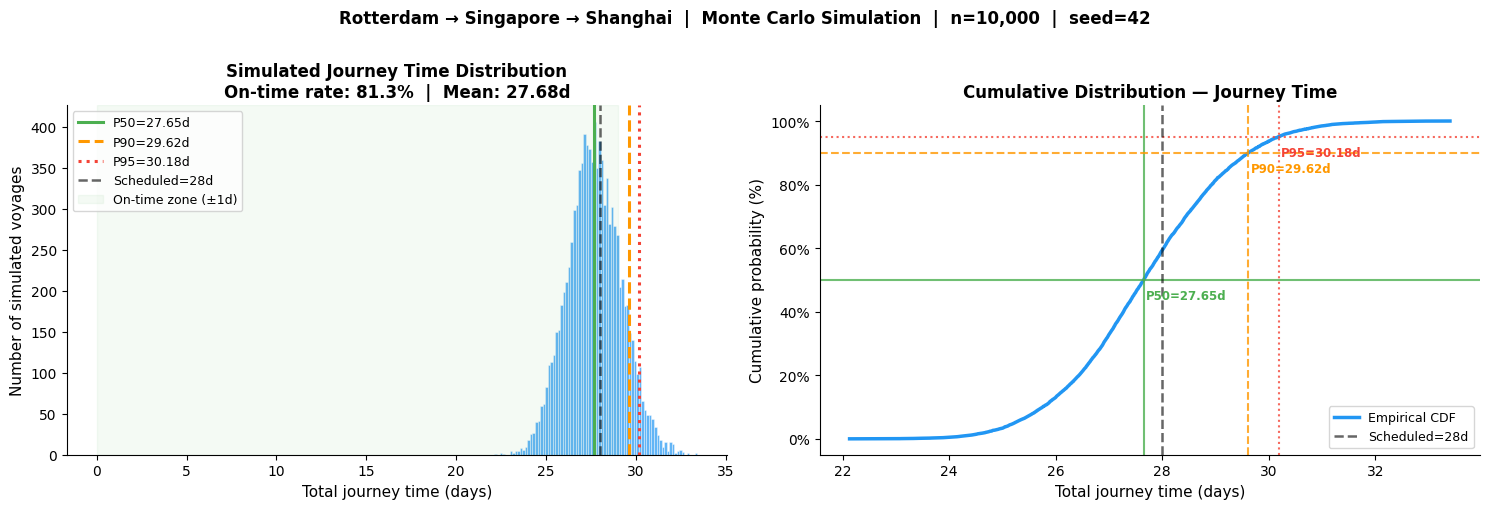

Saved: figures/simulation/journey_time_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel 1: Histogram with percentile markers ─────────────────────────────
ax1 = axes[0]
ax1.hist(results, bins=80, color='#2196F3', alpha=0.7,
         edgecolor='white', linewidth=0.4, density=False)

pct_markers = [
    (50, '#4CAF50', 'solid',  f'P50={np.percentile(results,50):.2f}d'),
    (90, '#FF9800', 'dashed', f'P90={np.percentile(results,90):.2f}d'),
    (95, '#F44336', 'dotted', f'P95={np.percentile(results,95):.2f}d'),
]
for pct, color, ls, label in pct_markers:
    val = np.percentile(results, pct)
    ax1.axvline(val, color=color, linewidth=2.2,
                linestyle=ls, label=label)

ax1.axvline(SCHEDULED, color='black', linewidth=1.8,
            linestyle='--', alpha=0.6, label=f'Scheduled={SCHEDULED:.0f}d')

# Shade on-time zone
ax1.axvspan(0, SCHEDULED + BUFFER_DAYS,
            alpha=0.06, color='#4CAF50', label=f'On-time zone (±{BUFFER_DAYS:.0f}d)')

ax1.set_xlabel('Total journey time (days)', fontsize=11)
ax1.set_ylabel('Number of simulated voyages', fontsize=11)
ax1.set_title(
    f'Simulated Journey Time Distribution\n'
    f'On-time rate: {summary["on_time_rate_pct"]:.1f}%  |  '
    f'Mean: {summary["mean_days"]:.2f}d'
)
ax1.legend(fontsize=9)

# ── Panel 2: Empirical CDF ──────────────────────────────────────────────────
ax2 = axes[1]
sorted_r = np.sort(results)
ecdf     = np.arange(1, len(results) + 1) / len(results)

ax2.plot(sorted_r, ecdf * 100, color='#2196F3',
         linewidth=2.5, label='Empirical CDF')

for pct, color, ls, label in pct_markers:
    val = np.percentile(results, pct)
    ax2.axhline(pct, color=color, linewidth=1.5,
                linestyle=ls, alpha=0.8)
    ax2.axvline(val, color=color, linewidth=1.5,
                linestyle=ls, alpha=0.8)
    ax2.annotate(
        f'{label}',
        xy=(val, pct),
        xytext=(val + 0.05, pct - 6),
        fontsize=8.5, color=color, fontweight='bold'
    )

ax2.axvline(SCHEDULED, color='black', linewidth=1.8,
            linestyle='--', alpha=0.6,
            label=f'Scheduled={SCHEDULED:.0f}d')

ax2.set_xlabel('Total journey time (days)', fontsize=11)
ax2.set_ylabel('Cumulative probability (%)', fontsize=11)
ax2.set_title('Cumulative Distribution — Journey Time')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle(
    'Rotterdam → Singapore → Shanghai  |  '
    f'Monte Carlo Simulation  |  n={N_ITERATIONS:,}  |  seed={SEED}',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / 'journey_time_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/simulation/journey_time_distribution.png')

---
## Segment Contribution Analysis

Which segments contribute most to total journey time and variability?

Segment contributions to total journey time:
                      segment  mean_days  std_days  p90_days  pct_of_total
Rotterdam → Singapore transit    21.0195    1.2634   22.6341         75.94
 Singapore → Shanghai transit     3.9989    0.2401    4.3077         14.45
         Singapore port delay     0.9908    0.4908    1.6468          3.58
         Rotterdam port delay     0.9235    0.4675    1.5524          3.34
          Shanghai port delay     0.7473    0.3916    1.2651          2.70


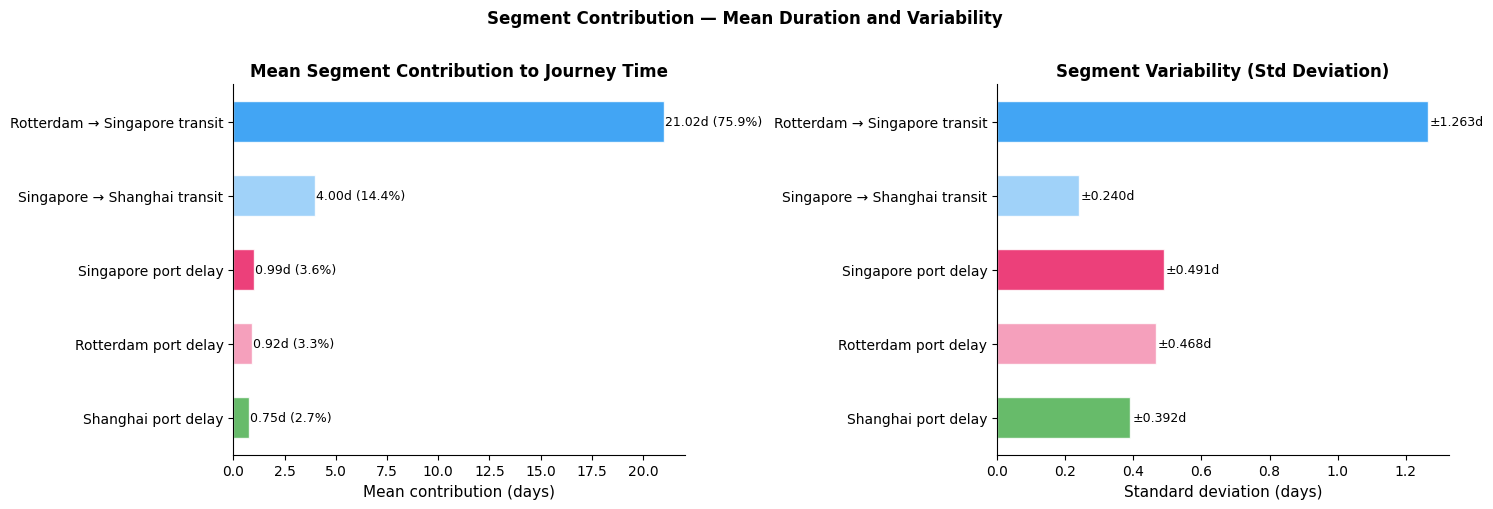

Saved: figures/simulation/segment_contributions.png


In [8]:
contrib = sim.segment_contribution()

print('Segment contributions to total journey time:')
print(contrib.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel 1: Mean contribution (stacked bar concept as horizontal bars) ────
colors_seg = ['#2196F3', '#90CAF9', '#E91E63', '#F48FB1', '#4CAF50']
bars = axes[0].barh(
    contrib['segment'],
    contrib['mean_days'],
    color=colors_seg,
    alpha=0.85,
    height=0.55,
    edgecolor='white'
)
for bar, row in zip(bars, contrib.itertuples()):
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{row.mean_days:.2f}d ({row.pct_of_total:.1f}%)',
        va='center', fontsize=9
    )
axes[0].set_xlabel('Mean contribution (days)', fontsize=11)
axes[0].set_title('Mean Segment Contribution to Journey Time')
axes[0].invert_yaxis()

# ── Panel 2: Variability (std per segment) ─────────────────────────────────
bars2 = axes[1].barh(
    contrib['segment'],
    contrib['std_days'],
    color=colors_seg,
    alpha=0.85,
    height=0.55,
    edgecolor='white'
)
for bar, row in zip(bars2, contrib.itertuples()):
    axes[1].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'±{row.std_days:.3f}d',
        va='center', fontsize=9
    )
axes[1].set_xlabel('Standard deviation (days)', fontsize=11)
axes[1].set_title('Segment Variability (Std Deviation)')
axes[1].invert_yaxis()

plt.suptitle('Segment Contribution — Mean Duration and Variability',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'segment_contributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/simulation/segment_contributions.png')

---
## Sensitivity Analysis — Tornado Chart

For each segment, we apply a **+30% shock** to its delay distribution's scale
parameter and measure the resulting change in P90 journey time.

This answers: *"Which segment, if it deteriorated by 30%, would hurt reliability the most?"*

In [9]:
print('Running sensitivity analysis (+30% shock per segment)...')

sensitivity_df = run_sensitivity(
    simulator    = sim,
    shock_pct    = 0.30,
    n_iterations = N_ITERATIONS,
    metric       = 'p90'
)

print('\nSensitivity results:')
print(sensitivity_df[['segment','base_metric','shocked_metric',
                        'delta','delta_pct']].to_string(index=False))

Running sensitivity analysis (+30% shock per segment)...

Sensitivity results:
                      segment  base_metric  shocked_metric  delta  delta_pct
Rotterdam → Singapore transit       29.618         30.0743 0.4563       1.54
         Singapore port delay       29.618         29.9937 0.3757       1.27
         Rotterdam port delay       29.618         29.9660 0.3480       1.17
          Shanghai port delay       29.618         29.8895 0.2716       0.92
 Singapore → Shanghai transit       29.618         29.6451 0.0271       0.09


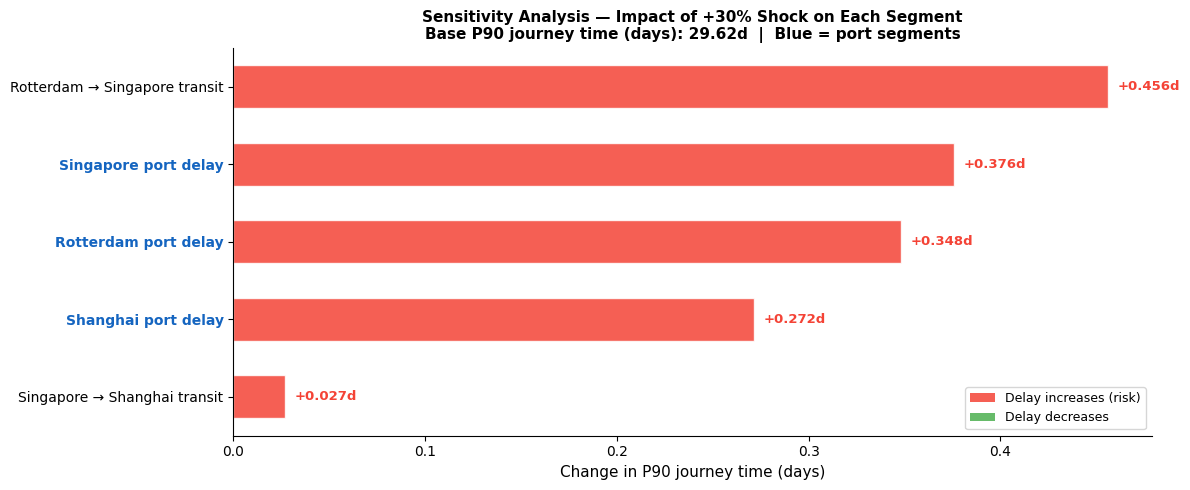

Saved: figures/simulation/tornado_chart.png
Saved: outputs/sensitivity_results.csv


In [10]:
base_p90 = float(np.percentile(results, 90))

fig = plot_tornado(
    sensitivity_df    = sensitivity_df,
    base_metric_value = base_p90,
    shock_pct         = 0.30,
    metric_label      = 'P90 journey time (days)'
)
fig.savefig(FIGURES / 'tornado_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/simulation/tornado_chart.png')

# Save sensitivity data
sensitivity_df.to_csv(OUTPUTS / 'sensitivity_results.csv', index=False)
print('Saved: outputs/sensitivity_results.csv')

---
## Scenario Comparison

We compare three scenarios to show how congestion conditions affect reliability:

| Scenario | Description |
|---|---|
| **Baseline** | 2023 actual average congestion |
| **High congestion** | All ports at 30% above baseline (stress test) |
| **Low congestion** | All ports at 20% below baseline (favourable) |

In [11]:
def build_and_run(
    route, fitted, congestion_indices, seed=SEED, n=N_ITERATIONS
):
    """Helper — build simulator with given congestion indices and run."""
    s = MonteCarloSimulator(
        route              = route,
        seed               = seed,
        fitted_params      = fitted,
        congestion_indices = congestion_indices
    )
    return s.run(n)


# ── Three scenarios ────────────────────────────────────────────────────────
scenarios_ci = {
    'Baseline (2023 CI)': CONGESTION_2023,
    'High congestion (+30%)': {
        p: min(ci * 1.30, 2.0)
        for p, ci in CONGESTION_2023.items()
    },
    'Low congestion (−20%)': {
        p: max(ci * 0.80, 0.5)
        for p, ci in CONGESTION_2023.items()
    }
}

print('Congestion indices per scenario:')
for scenario, ci_dict in scenarios_ci.items():
    print(f'  {scenario}')
    for port, ci in ci_dict.items():
        mult = get_congestion_multiplier(ci, port, fitted)
        print(f'    {port:<12} CI={ci:.4f}  multiplier={mult:.4f}')

print('\nRunning scenarios...')
scenario_results = {
    name: build_and_run(route, fitted, ci_dict)
    for name, ci_dict in scenarios_ci.items()
}
print('Done.')

Congestion indices per scenario:
  Baseline (2023 CI)
    Rotterdam    CI=0.8868  multiplier=0.9660
    Singapore    CI=0.9954  multiplier=1.0023
    Shanghai     CI=1.1180  multiplier=1.0000
  High congestion (+30%)
    Rotterdam    CI=1.1528  multiplier=1.0459
    Singapore    CI=1.2940  multiplier=0.8530
    Shanghai     CI=1.4534  multiplier=1.0000
  Low congestion (−20%)
    Rotterdam    CI=0.7094  multiplier=0.9128
    Singapore    CI=0.7963  multiplier=1.1018
    Shanghai     CI=0.8944  multiplier=1.0000

Running scenarios...
Done.


In [12]:
# ── KPI comparison table ───────────────────────────────────────────────────
comparison = compare_scenarios(scenario_results, SCHEDULED, BUFFER_DAYS)

print('=' * 70)
print('  SCENARIO COMPARISON')
print('=' * 70)
display_cols = ['mean_days','std_days','p50_days','p90_days',
                'p95_days','on_time_rate_pct','reliability_buffer_d']
print(comparison[display_cols].round(4).to_string())
print('=' * 70)

# Save
comparison.to_csv(OUTPUTS / 'scenario_comparison.csv')
print('\nSaved: outputs/scenario_comparison.csv')

  SCENARIO COMPARISON
                        mean_days  std_days  p50_days  p90_days  p95_days  on_time_rate_pct  reliability_buffer_d
scenario                                                                                                         
Baseline (2023 CI)        27.6799    1.4995   27.6512   29.6180   30.1843             81.35                1.6180
High congestion (+30%)    27.6086    1.4887   27.5807   29.5268   30.0872             82.58                1.5268
Low congestion (−20%)     27.7275    1.5092   27.6981   29.6741   30.2371             80.23                1.6741

Saved: outputs/scenario_comparison.csv


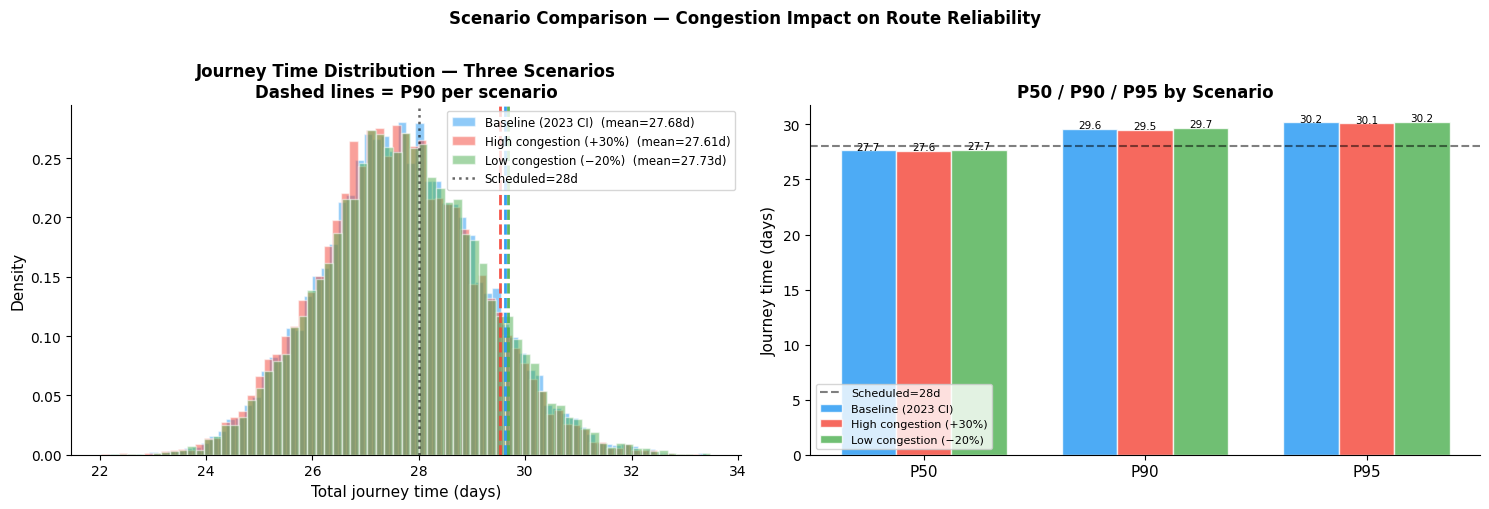

Saved: figures/simulation/scenario_comparison.png


In [13]:
# ── Scenario visualisation ─────────────────────────────────────────────────
scenario_colors = ['#2196F3', '#F44336', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Overlapping distributions
for (name, res), color in zip(scenario_results.items(), scenario_colors):
    axes[0].hist(res, bins=70, density=True, alpha=0.5,
                 color=color, edgecolor='white',
                 label=f'{name}  (mean={res.mean():.2f}d)')
    p90 = np.percentile(res, 90)
    axes[0].axvline(p90, color=color, linewidth=2,
                    linestyle='--', alpha=0.9)

axes[0].axvline(SCHEDULED, color='black', linewidth=1.8,
                linestyle=':', alpha=0.6, label=f'Scheduled={SCHEDULED:.0f}d')
axes[0].set_xlabel('Total journey time (days)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Journey Time Distribution — Three Scenarios\n'
                   'Dashed lines = P90 per scenario')
axes[0].legend(fontsize=8.5)

# Panel 2: KPI bar chart
kpi_names    = ['p50_days', 'p90_days', 'p95_days']
kpi_labels   = ['P50', 'P90', 'P95']
x            = np.arange(len(kpi_names))
width        = 0.25
scenario_names = list(scenario_results.keys())

for i, (name, color) in enumerate(zip(scenario_names, scenario_colors)):
    vals = [comparison.loc[name, k] for k in kpi_names]
    bars = axes[1].bar(x + i * width, vals, width,
                       label=name, color=color, alpha=0.8,
                       edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', fontsize=7.5
        )

axes[1].axhline(SCHEDULED, color='black', linewidth=1.5,
                linestyle='--', alpha=0.5,
                label=f'Scheduled={SCHEDULED:.0f}d')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(kpi_labels, fontsize=11)
axes[1].set_ylabel('Journey time (days)', fontsize=11)
axes[1].set_title('P50 / P90 / P95 by Scenario')
axes[1].legend(fontsize=8)

plt.suptitle('Scenario Comparison — Congestion Impact on Route Reliability',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'scenario_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/simulation/scenario_comparison.png')

---
##  Deterministic vs Stochastic Planning

This section directly demonstrates the core value of simulation over
deterministic planning.

A deterministic planner assumes the ship always arrives in exactly 28 days.
The simulation shows what actually happens.

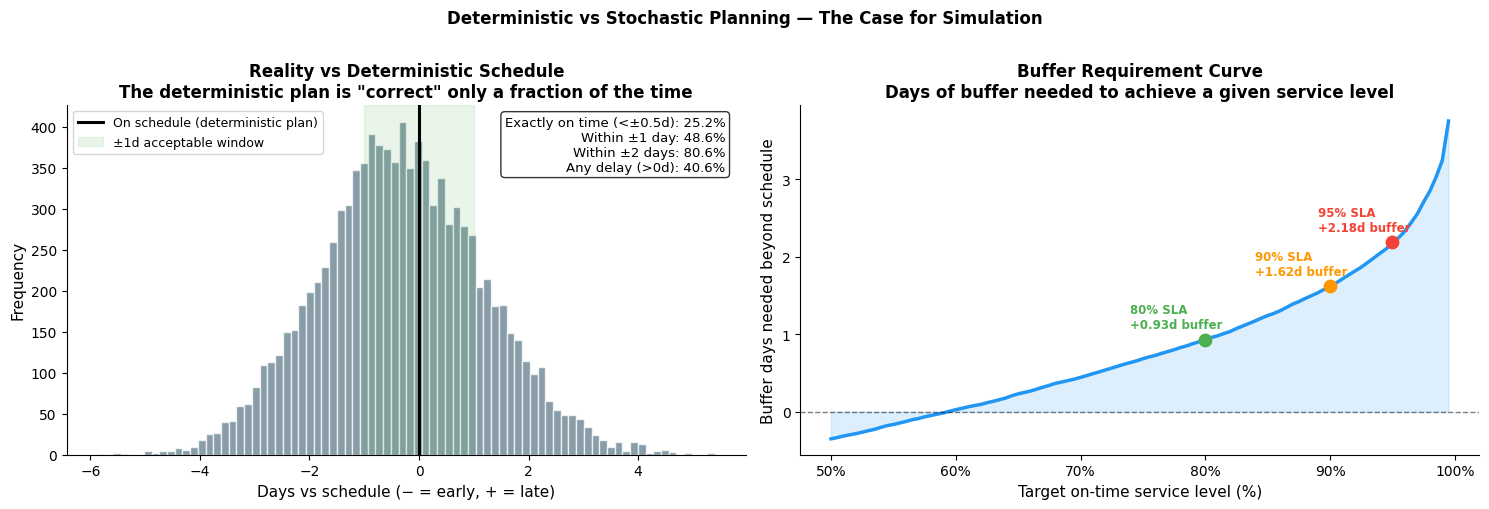

In [15]:
variance_from_schedule = results - SCHEDULED

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Variance from schedule
axes[0].hist(variance_from_schedule, bins=80,
             color='#607D8B', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=2.2,
                label='On schedule (deterministic plan)')
axes[0].axvspan(-BUFFER_DAYS, BUFFER_DAYS, alpha=0.12,
                color='#4CAF50', label=f'±{BUFFER_DAYS:.0f}d acceptable window')

pct_exact    = (np.abs(variance_from_schedule) < 0.5).mean() * 100
pct_within_1 = (np.abs(variance_from_schedule) < 1.0).mean() * 100
pct_within_2 = (np.abs(variance_from_schedule) < 2.0).mean() * 100
pct_late     = (variance_from_schedule > 0).mean() * 100

axes[0].text(
    0.97, 0.97,
    f'Exactly on time (<±0.5d): {pct_exact:.1f}%\n'
    f'Within ±1 day: {pct_within_1:.1f}%\n'
    f'Within ±2 days: {pct_within_2:.1f}%\n'
    f'Any delay (>0d): {pct_late:.1f}%',
    transform=axes[0].transAxes,
    va='top', ha='right', fontsize=9.5,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axes[0].set_xlabel('Days vs schedule (− = early, + = late)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Reality vs Deterministic Schedule\n'
                   'The deterministic plan is "correct" only a fraction of the time')
axes[0].legend(fontsize=9)

# Panel 2: Buffer requirement curve
# "How much buffer do you need to guarantee X% on-time delivery?"
target_pcts = np.arange(50, 100, 0.5)
buffers     = [np.percentile(results, p) - SCHEDULED for p in target_pcts]

axes[1].plot(target_pcts, buffers, color='#2196F3', linewidth=2.5)
axes[1].fill_between(target_pcts, buffers, alpha=0.15, color='#2196F3')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

# Annotate key service levels
for target, color in [(80, '#4CAF50'), (90, '#FF9800'), (95, '#F44336')]:
    buf = np.percentile(results, target) - SCHEDULED
    axes[1].scatter(target, buf, color=color, s=80, zorder=5)
    axes[1].annotate(
        f'{target}% SLA\n+{buf:.2f}d buffer',
        xy=(target, buf),
        xytext=(target - 6, buf + 0.15),
        fontsize=8.5, color=color, fontweight='bold'
    )

axes[1].set_xlabel('Target on-time service level (%)', fontsize=11)
axes[1].set_ylabel('Buffer days needed beyond schedule', fontsize=11)
axes[1].set_title('Buffer Requirement Curve\n'
                   'Days of buffer needed to achieve a given service level')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Deterministic vs Stochastic Planning — The Case for Simulation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'deterministic_vs_stochastic.png',
            dpi=150, bbox_inches='tight')
plt.show()


---
## Reproducibility Verification

In [16]:
# Re-run with same seed — results must be identical
sim_check = MonteCarloSimulator(
    route              = route,
    seed               = SEED,
    fitted_params      = fitted,
    congestion_indices = CONGESTION_2023
)
results_check = sim_check.run(N_ITERATIONS)

identical = np.array_equal(results, results_check)
print(f'Reproducibility check (same seed={SEED}):')
print(f'  Results identical: {identical} ✓' if identical
      else f'  ✗ Results differ — check seed handling')
print(f'  Max absolute difference: {np.abs(results - results_check).max()}')

Reproducibility check (same seed=42):
  Results identical: True ✓
  Max absolute difference: 0.0


---
## Save All Outputs

In [17]:
# Save simulation results array
np.save(OUTPUTS / 'simulation_results_baseline.npy', results)

# Save segment contributions
contrib.to_csv(OUTPUTS / 'segment_contributions.csv', index=False)

# Save full summary as JSON
full_summary = {
    'route':               route.name,
    'scheduled_days':      SCHEDULED,
    'n_iterations':        N_ITERATIONS,
    'seed':                SEED,
    'congestion_year':     2023,
    'congestion_indices':  CONGESTION_2023,
    'kpis':                kpis.drop('scenario').to_dict(),
    'segment_contributions': contrib.to_dict(orient='records'),
    'sensitivity_top3':    sensitivity_df.head(3)[['segment','delta','delta_pct']]
                           .to_dict(orient='records')
}
with open(OUTPUTS / 'simulation_summary.json', 'w') as f:
    json.dump(full_summary, f, indent=2)

print('All outputs saved:')
for f in sorted(OUTPUTS.glob('*')):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size:>7.1f} KB')

All outputs saved:
  kpi_report_baseline.json                          0.3 KB
  scenario_comparison.csv                           0.5 KB
  segment_contributions.csv                         0.3 KB
  sensitivity_results.csv                           0.3 KB
  simulation_results_baseline.npy                  78.2 KB
  simulation_summary.json                           1.8 KB


## Conclusions

---

### 1.Route Reliability — What the Simulation Tells Us

Under 2023 operating conditions, the Rotterdam → Singapore → Shanghai route
performs close to — but slightly under — its 28-day schedule. The simulated
mean of **27.68 days** suggests vessels are marginally faster than the scheduled
time on average, which might be because modern mega-vessels on this lane
consistently run at optimised speeds and Rotterdam's 2023 congestion index
was notably below baseline (CI = 0.887), reflecting quieter post-COVID
European port conditions.

The more important finding is in the **tail behaviour**. While the mean looks
reassuring, the P90 of **29.62 days** means that 1 in 10 voyages will take
nearly two days longer than planned. At scale — running hundreds of vessels
on this lane — that tail materialises constantly. Planners relying on the
scheduled 28 days alone will be wrong roughly 59% of the time in either
direction, and late by more than 2 days on **6.35%** of voyages.

The simulation quantifies what that means for service level commitments:

| Service level target | Buffer needed beyond schedule |
|---|---|
| 80% on-time | 0.68 days |
| 90% on-time | 1.62 days |
| 95% on-time | 2.18 days |

---

### 2.Segment Contributions — Where the Journey Time Goes

The dominant segment is the **Rotterdam → Singapore transit**, accounting for
**75.9%** of mean journey time at 21.02 days. However, its role as the primary
driver of variability is the more operationally relevant finding — with a
standard deviation of **1.26 days**, this single leg contributes more
uncertainty than all three port calls combined (total port std ≈ 0.76 days).

The **Singapore → Shanghai transit** is proportionally short (14.4% of journey
time) but highly predictable (std = 0.24 days), suggesting this leg is
well-controlled. Port delays at all three stops are small in absolute terms
but right-skewed — their P90 values are roughly double their means, meaning
occasional severe port delays are possible even when typical stays are short.

---

### 3. Sensitivity Analysis — What Drives Risk

The tornado chart reveals a clear risk hierarchy:

**Rotterdam → Singapore transit** is the highest-risk segment. A 30% increase
in variability adds **+0.46 days** to P90 — more than any single port.
This might be because this leg spans the longest open-ocean distance, crossing
weather-exposed zones in the Indian Ocean and Bay of Bengal where routing
deviations accumulate over a 21-day voyage.

**Singapore port delay** ranks second (+0.38d), notable given that its mean
dwell time is under a day. This might reflect Singapore's sensitivity to
network-wide disruptions rather than local traffic — the inverse congestion
relationship found in EDA means quieter periods correlate with longer stays,
making this port harder to buffer against through conventional planning.

**Rotterdam port delay** ranks third (+0.35d), consistent with its moderate
congestion sensitivity and the 2023 below-baseline congestion index.

**Singapore → Shanghai transit** is by far the least sensitive segment
(+0.03d). A 30% shock has almost no effect on P90, confirming it is a
short, well-managed, low-variability leg requiring minimal operational
attention from a reliability standpoint.

An important counter-intuitive finding: port delays together contribute
**+1.00d** to P90 under a 30% shock, while transit legs contribute **+0.48d**.
Despite ports accounting for only ~10% of journey time, their combined
sensitivity exceeds that of transit legs — suggesting port operations
collectively drive more reliability risk per unit of deterioration.

---

### 4. Scenario Comparison — Congestion Sensitivity

Perhaps the most surprising finding is how **insensitive** this route is to
congestion changes. Across the three scenarios — baseline, +30% congestion,
and −20% congestion — the P90 spread is only **0.15 days** and the on-time
rate spread is only **2.35 percentage points**.

This is a direct consequence of the EDA findings from Notebook 01: the
congestion–dwell time relationship is weak or inverse at all three ports.
Rotterdam's dampened multiplier limits the congestion effect. Singapore's
inverse multiplier means higher congestion *improves* its delay performance
slightly. Shanghai has no multiplier at all.

The practical implication is that for this specific route, **transit time
variability on the long-haul leg dominates reliability** far more than port
congestion does. Operational investment aimed at reducing schedule variability
on the Rotterdam–Singapore leg would likely yield more reliability improvement
than congestion reduction at any individual port.

---

### 5. Deterministic vs Stochastic Planning

The variance breakdown makes the strongest case for simulation:

| Variance band | Share of simulated voyages |
|---|---|
| Early > 2 days | 13.0% |
| Early 1–2 days | 19.7% |
| Early < 1 day | 26.6% |
| Late < 1 day | 22.0% |
| Late 1–2 days | 12.3% |
| Late > 2 days | 6.4% |

Only **~27%** of voyages arrive within half a day of the schedule. A
deterministic planner treating 28 days as a fixed commitment will be surprised
by almost every vessel. The simulation replaces that single number with a full
probability distribution, enabling statements like:

> *"We can commit to 29.6-day delivery with 90% confidence, or 30.2-day
> delivery with 95% confidence, under current 2023 operating conditions."*

That is a fundamentally different — and more operationally honest — basis
for network design decisions.

---

### 6. Limitations & Future Work

| Limitation | Impact | Possible improvement |
|---|---|---|
| 6 annual UNCTAD medians per port | Fitting relies on synthesised samples, not raw observations | Obtain vessel-level AIS arrival/departure data |
| Transit variability modelled as Normal with fixed 6% CV | May underestimate tail risk on weather-exposed legs | Calibrate CV from actual vessel tracking data per season |
| Congestion multipliers from limited annual data points | Low statistical confidence in multiplier coefficients | More granular time-series regression with monthly data |
| Singapore 2018–2021 medians imputed | Introduces uncertainty in pre-COVID Singapore baseline | Obtain UNCTAD data directly from MPA Singapore |
| No spatial correlation between disruptions | Real disruptions (e.g. Suez blockage) affect all segments simultaneously | Add correlated disruption shock model |
| Single route modelled | Cannot compare network design alternatives directly | Extend to direct Rotterdam–Shanghai route for head-to-head comparison |

---

## Summary

```
Route          : Rotterdam → Singapore → Shanghai
Scheduled      : 28.0 days
Simulated mean : 27.68 days  (slightly faster than schedule on average)

Reliability KPIs (seed=42, n=10,000, 2023 congestion):
  P50 : 27.65 days
  P90 : 29.62 days   ← reliability buffer: +1.62 days over schedule
  P95 : 30.18 days
  On-time rate (±1d) : 81.35%

Primary risk driver  : Rotterdam → Singapore transit (+0.46d P90 per 30% shock)
Most sensitive port  : Singapore (+0.38d P90 per 30% shock)
Congestion impact    : Low — P90 spread of only 0.15d across all scenarios
Most predictable leg : Singapore → Shanghai transit (std=0.24d, sensitivity=+0.03d)
Most stable metric   : CV = 0.054 (tight distribution around the mean)
```
